In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\Ameet Computer\Music\ML engineer projects\Telco churn ML project\WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# 1. Separate X and y
x = df.drop("Churn", axis=1)
y = df["Churn"]

# 2. Remove ID
x = x.drop("customerID", axis=1)

# 3. Convert categorical columns to numeric
x = pd.get_dummies(x, drop_first=True)

# 4. Convert target
y = y.map({"No": 0, "Yes": 1})

In [4]:
import joblib
joblib.dump(list(x.columns),"columns.pkl")

['columns.pkl']

In [5]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [6]:
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.fit_transform(x_test)

In [7]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

In [8]:
# Linear model
from sklearn.linear_model import LogisticRegression

# Tree models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier)

In [9]:
from xgboost import XGBClassifier

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

lr = LogisticRegression(max_iter=2000)

lr.fit(x_train_scaled, y_train)

y_pred_lr = lr.predict(x_test_scaled)

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))
print("Classification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression
Accuracy: 0.7735982966643009
Confusion Matrix:
[[913 122]
 [197 177]]
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.88      0.85      1035
           1       0.59      0.47      0.53       374

    accuracy                           0.77      1409
   macro avg       0.71      0.68      0.69      1409
weighted avg       0.76      0.77      0.76      1409



In [11]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(x_train_scaled, y_train)
y_pred_dt = dt.predict(x_test_scaled)

print("DecisionTreeClassifier")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))
print("Classification Report:")
print(classification_report(y_test, y_pred_dt))

DecisionTreeClassifier
Accuracy: 0.7721788502484032
Confusion Matrix:
[[911 124]
 [197 177]]
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.88      0.85      1035
           1       0.59      0.47      0.52       374

    accuracy                           0.77      1409
   macro avg       0.71      0.68      0.69      1409
weighted avg       0.76      0.77      0.76      1409



In [12]:
rf = RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(x_train_scaled,y_train)
y_pred_rf = rf.predict(x_test_scaled)

print("RandomForestClassifier")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("Classification Report:")
print(classification_report(y_test, y_pred_rf))


RandomForestClassifier
Accuracy: 0.794889992902768
Confusion Matrix:
[[957  78]
 [211 163]]
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.92      0.87      1035
           1       0.68      0.44      0.53       374

    accuracy                           0.79      1409
   macro avg       0.75      0.68      0.70      1409
weighted avg       0.78      0.79      0.78      1409



In [13]:
xg = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xg.fit(x_train_scaled, y_train)

y_pred_xg = xg.predict(x_test_scaled)

print("XGBClassifier")
print("Accuracy:", accuracy_score(y_test, y_pred_xg))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xg))
print("Classification Report:")
print(classification_report(y_test, y_pred_xg))

XGBClassifier
Accuracy: 0.7643718949609652
Confusion Matrix:
[[881 154]
 [178 196]]
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.85      0.84      1035
           1       0.56      0.52      0.54       374

    accuracy                           0.76      1409
   macro avg       0.70      0.69      0.69      1409
weighted avg       0.76      0.76      0.76      1409



In [14]:

from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42)

gb.fit(x_train, y_train)

y_pred_gb = gb.predict(x_test)

print("Gradient Boosting")
print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_gb))
print("Classification Report:")
print(classification_report(y_test, y_pred_gb))

Gradient Boosting
Accuracy: 0.7934705464868701
Confusion Matrix:
[[937  98]
 [193 181]]
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1035
           1       0.65      0.48      0.55       374

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



In [15]:
from lightgbm import LGBMClassifier
lgbm = LGBMClassifier(
    random_state=42,
    verbosity=-1
)

lgbm.fit(x_train, y_train)

y_pred_lgbm = lgbm.predict(x_test)

print("LightGBM")
print("Accuracy:", accuracy_score(y_test, y_pred_lgbm))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lgbm))
print("Classification Report:")
print(classification_report(y_test, y_pred_lgbm))

LightGBM
Accuracy: 0.7955997161107168
Confusion Matrix:
[[919 116]
 [172 202]]
Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.64      0.54      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [16]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

knn.fit(x_train_scaled, y_train)

y_pred_knn = knn.predict(x_test_scaled)

print("KNN")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))
print("Classification Report:")
print(classification_report(y_test, y_pred_knn))

KNN
Accuracy: 0.7345635202271115
Confusion Matrix:
[[1032    3]
 [ 371    3]]
Classification Report:
              precision    recall  f1-score   support

           0       0.74      1.00      0.85      1035
           1       0.50      0.01      0.02       374

    accuracy                           0.73      1409
   macro avg       0.62      0.50      0.43      1409
weighted avg       0.67      0.73      0.63      1409



In [17]:
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": (lr, x_test_scaled),
    "Decision Tree": (dt, x_test),
    "Random Forest": (rf, x_test),
    "Gradient Boosting": (gb, x_test),
    "XGBoost": (xg, x_test),
    "LightGBM": (lgbm, x_test),
    "KNN": (knn, x_test_scaled)
}

for name, (model, X) in models.items():
    y_pred = model.predict(X)
    accuracy = accuracy_score(y_test, y_pred)

    print(name, ":", accuracy)

Logistic Regression : 0.7735982966643009
Decision Tree : 0.723207948899929


C:\Users\Ameet Computer\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
C:\Users\Ameet Computer\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


Random Forest : 0.7366926898509581
Gradient Boosting : 0.7934705464868701
XGBoost : 0.7331440738112136
LightGBM : 0.7955997161107168
KNN : 0.7345635202271115


In [21]:
from sklearn.metrics import roc_auc_score

for name, (model, X) in models.items():
    y_prob = model.predict_proba(X)[:, 1]
    auc = roc_auc_score(y_test, y_prob)

    print(name, "-> ROC-AUC:", round(auc, 4))

Logistic Regression -> ROC-AUC: 0.8075
Decision Tree -> ROC-AUC: 0.6835


C:\Users\Ameet Computer\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
C:\Users\Ameet Computer\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


Random Forest -> ROC-AUC: 0.7913
Gradient Boosting -> ROC-AUC: 0.8451
XGBoost -> ROC-AUC: 0.5409
LightGBM -> ROC-AUC: 0.8348
KNN -> ROC-AUC: 0.536


C:\Users\Ameet Computer\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
C:\Users\Ameet Computer\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


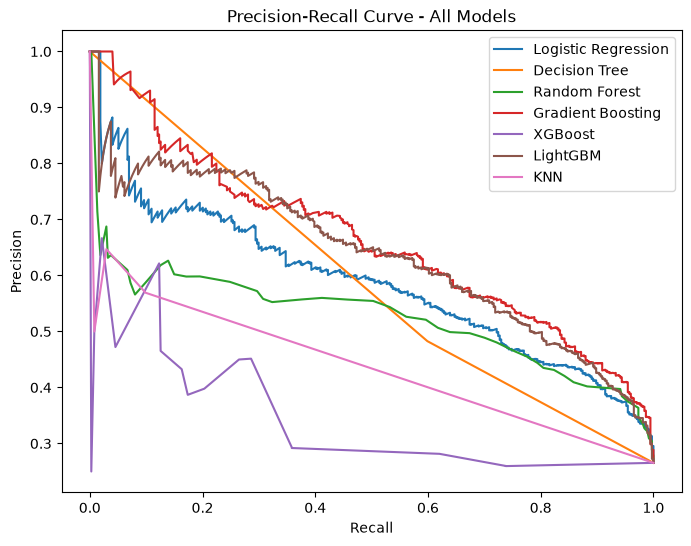

In [22]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

for name, (model, X) in models.items():

    y_prob = model.predict_proba(X)[:, 1]

    precision, recall, _ = precision_recall_curve(y_test, y_prob)

    plt.plot(recall, precision, label=name)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - All Models")
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

for name, (model, X) in models.items():

    y_prob = model.predict_proba(X)[:, 1]

    precision, recall, _ = precision_recall_curve(y_test, y_prob)

    plt.plot(recall, precision, label=name)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - All Models")
plt.legend()
plt.show()

In [23]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

x_train_smote, y_train_smote = smote.fit_resample(
    x_train_scaled,
    y_train
)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_smote.value_counts().to_dict())


Before SMOTE: {0: 4139, 1: 1495}
After SMOTE: {0: 4139, 1: 4139}


In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

rf = RandomForestClassifier(
    random_state=42,
    class_weight="balanced"
)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(x_train_scaled, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV F1 Score:", grid_search.best_score_)

Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
Best CV F1 Score: 0.6316065982939402


In [26]:
best_rf = grid_search.best_estimator_

y_pred = best_rf.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

C:\Users\Ameet Computer\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


Accuracy: 0.7665010645848119
              precision    recall  f1-score   support

           0       0.77      0.96      0.86      1035
           1       0.69      0.22      0.34       374

    accuracy                           0.77      1409
   macro avg       0.73      0.59      0.60      1409
weighted avg       0.75      0.77      0.72      1409



In [27]:
import joblib

joblib.dump(best_rf, "telco_churn_model.pkl")

print("Model saved")

Model saved


In [28]:
from fastapi import FastAPI
import pandas as pd
import joblib

app = FastAPI()

# Load model
model = joblib.load("telco_churn_model.pkl")


@app.post("/predict")
def predict(data: dict):

    # Convert input to DataFrame
    df_input = pd.DataFrame([data])

    # Remove customer ID if present
    if "customerID" in df_input.columns:
        df_input = df_input.drop("customerID", axis=1)

    # Convert categorical variables
    df_input = pd.get_dummies(df_input, drop_first=True)

    # Make columns exactly the same as training data
    df_input = df_input.reindex(
        columns=model.feature_names_in_,
        fill_value=0
    )

    # Prediction
    prediction = model.predict(df_input)[0]

    # Probability
    probability = model.predict_proba(df_input)[0][1]

    return {
        "prediction": "Yes" if prediction == 1 else "No",
        "probability_of_yes": round(float(probability), 4)
    }

In [ ]:
import streamlit
import requests

print("Streamlit:", streamlit.__version__)
print("Successfully imported Streamlit and Requests!")

Streamlit: 1.51.0
Successfully imported Streamlit and Requests!
